# Supervisor difuso multivariable para la gestión térmica de una batería de flujo redox de vanadio

Implementación en Python de un supervisor basado en lógica difusa (inferencia de tipo Mamdani, biblioteca `scikit-fuzzy`) que calcula tres consignas normalizadas — actuador de acondicionamiento térmico, bomba de recirculación y potencia de carga/descarga — a partir de cuatro entradas: temperatura del electrolito, temperatura ambiente, estado de carga (SoC) y una señal normalizada del estado de la red.

El sistema se evalúa únicamente mediante simulación: no incorpora datos experimentales de una batería real ni un modelo dinámico de planta. Las funciones de pertenencia, los umbrales y la tabla de decisión son hipótesis de diseño.

**Contenido**
1. Configuración
2. Variables de entrada (antecedentes)
3. Riesgo térmico efectivo
4. Variables de salida (consecuentes)
5. Base de reglas
6. Funciones de pertenencia
7. Escenarios de evaluación
8. Agregación y desfusificación de un caso
9. Verificación de cobertura
10. Superficies estáticas
11. Efecto de la temperatura ambiente
12. Comprobaciones de consistencia
13. Trayectoria sintética de 24 horas
14. Comparación con controladores por umbrales
15. Contraste de umbrales con literatura publicada
16. Traducción ilustrativa a magnitudes físicas

## 1. Configuración

In [1]:
# Libreria para lógica difusa
!pip install scikit-fuzzy==0.5.0

error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try apt install
    python3-xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Debian-packaged Python package,
    create a virtual environment using python3 -m venv path/to/venv.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip. Make
    sure you have python3-full installed.
    
    If you wish to install a non-Debian packaged Python application,
    it may be easiest to use pipx install xyz, which will manage a
    virtual environment for you. Make sure you have pipx installed.
    
    See /usr/share/doc/python3.12/README.venv for more information.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detai

In [2]:
# Librerías complementarias para trabajar con números y gráficos y llamar a las funciones de la libreria anterior
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import matplotlib.pyplot as plt


In [3]:
import itertools
import pandas as pd
from scipy.ndimage import uniform_filter1d

## 2. Variables de entrada (antecedentes)

Cuatro entradas, cada una con tres etiquetas difusas (trapezoidales en los extremos, triangular en el centro), salvo la señal de red que usa las mismas tres categorías con otro significado.

In [4]:
temp_elec = ctrl.Antecedent(np.arange(-20, 21, 1), 'temp_elec')   # temperatura del electrolito (°C)
soc_v2    = ctrl.Antecedent(np.arange(0, 101, 1), 'soc_v2')        # estado de carga (%)
sgrid_v2  = ctrl.Antecedent(np.arange(-1, 1.1, 0.1), 'sgrid_v2')   # señal normalizada de red (p.u.)

temp_elec['Frozen'] = fuzz.trapmf(temp_elec.universe, [-20, -20, -5, 0])
temp_elec['Cold']   = fuzz.trimf(temp_elec.universe, [-5, 0, 5])
temp_elec['Safe']   = fuzz.trapmf(temp_elec.universe, [0, 5, 20, 20])

soc_v2['Low']    = fuzz.trapmf(soc_v2.universe, [0, 0, 15, 40])
soc_v2['Medium'] = fuzz.trapmf(soc_v2.universe, [15, 40, 60, 85])
soc_v2['High']   = fuzz.trapmf(soc_v2.universe, [60, 85, 100, 100])

sgrid_v2['Demand']   = fuzz.trapmf(sgrid_v2.universe, [-1, -1, -0.5, 0])
sgrid_v2['Balanced'] = fuzz.trimf(sgrid_v2.universe, [-0.5, 0, 0.5])
sgrid_v2['Exceed']   = fuzz.trapmf(sgrid_v2.universe, [0, 0.5, 1, 1])

## 3. Riesgo térmico efectivo

La temperatura ambiente puede elevar el riesgo térmico del electrolito un nivel (sin superar `Frozen`), pero nunca reducirlo. Es una regla heurística, no un cálculo de transferencia de calor.

In [5]:
RISK = {'Safe': 0, 'Cold': 1, 'Frozen': 2}
RISK_INV = {v: k for k, v in RISK.items()}

def effective_temp_label(t_elec_label, t_amb_label):
    r_elec = RISK[t_elec_label]
    r_amb = RISK[t_amb_label]
    r_eff = r_elec if r_amb <= r_elec else min(r_elec + 1, 2)
    return RISK_INV[r_eff]

## 4. Variables de salida (consecuentes)

Tres salidas normalizadas: potencia del actuador térmico y caudal de la bomba (0-100 %), y potencia de carga/descarga de la batería (-100 a 100 %, positivo = carga).

In [6]:
# Salidas físicas reales (sustituyen al índice único 'Protection')
heater = ctrl.Consequent(np.arange(0, 101, 1), 'heater')   # potencia del actuador térmico (%)
pump   = ctrl.Consequent(np.arange(0, 101, 1), 'pump')     # caudal de recirculación (%)
batt   = ctrl.Consequent(np.arange(-100, 101, 1), 'batt')  # potencia batería: + carga, - descarga (%)

for out in (heater, pump):
    out['Off']    = fuzz.trapmf(out.universe, [0, 0, 5, 20])
    out['Low']    = fuzz.trimf(out.universe, [10, 30, 50])
    out['Medium'] = fuzz.trimf(out.universe, [35, 55, 75])
    out['High']   = fuzz.trapmf(out.universe, [60, 80, 100, 100])

batt['StrongDischarge'] = fuzz.trapmf(batt.universe, [-100, -100, -70, -40])
batt['Discharge']       = fuzz.trimf(batt.universe, [-60, -30, 0])
batt['Neutral']         = fuzz.trimf(batt.universe, [-20, 0, 20])
batt['Charge']          = fuzz.trimf(batt.universe, [0, 30, 60])
batt['StrongCharge']    = fuzz.trapmf(batt.universe, [40, 70, 100, 100])


## 5. Base de reglas

Tabla de 27 decisiones (riesgo térmico efectivo × SoC × estado de red), desplegada en 81 reglas al tratar como entradas independientes las tres etiquetas de la temperatura del electrolito y las tres de la temperatura ambiente.

In [7]:
# Tabla de decisión diferenciada: (temp_efectiva, soc, sgrid) -> (heater, pump, batt)
DECISION_V2 = {
    ('Frozen','Low','Demand'):     ('Off',    'High',   'Neutral'),
    ('Frozen','Low','Balanced'):   ('Off',    'High',   'Neutral'),
    ('Frozen','Low','Exceed'):     ('High',   'Medium', 'StrongCharge'),
    ('Frozen','Medium','Demand'):  ('Off',    'High',   'Neutral'),
    ('Frozen','Medium','Balanced'):('Low',    'High',   'Neutral'),
    ('Frozen','Medium','Exceed'):  ('Medium', 'Medium', 'Charge'),
    ('Frozen','High','Demand'):    ('Medium', 'Medium', 'Discharge'),
    ('Frozen','High','Balanced'):  ('Medium', 'Medium', 'Discharge'),
    ('Frozen','High','Exceed'):    ('Off',    'High',   'Neutral'),

    ('Cold','Low','Demand'):       ('Off',    'Medium', 'Neutral'),
    ('Cold','Low','Balanced'):     ('Off',    'Medium', 'Neutral'),
    ('Cold','Low','Exceed'):       ('Medium', 'Medium', 'Charge'),
    ('Cold','Medium','Demand'):    ('Off',    'Medium', 'Neutral'),
    ('Cold','Medium','Balanced'):  ('Off',    'Medium', 'Neutral'),
    ('Cold','Medium','Exceed'):    ('Medium', 'Medium', 'Charge'),
    ('Cold','High','Demand'):      ('Off',    'Low',    'Neutral'),
    ('Cold','High','Balanced'):    ('Off',    'Low',    'Neutral'),
    ('Cold','High','Exceed'):      ('Off',    'Low',    'Neutral'),

    ('Safe','Low','Demand'):       ('Off', 'Off', 'Neutral'),
    ('Safe','Low','Balanced'):     ('Off', 'Off', 'Neutral'),
    ('Safe','Low','Exceed'):       ('Off', 'Off', 'Neutral'),
    ('Safe','Medium','Demand'):    ('Off', 'Off', 'Neutral'),
    ('Safe','Medium','Balanced'):  ('Off', 'Off', 'Neutral'),
    ('Safe','Medium','Exceed'):    ('Off', 'Off', 'Neutral'),
    ('Safe','High','Demand'):      ('Off', 'Off', 'Neutral'),
    ('Safe','High','Balanced'):    ('Off', 'Off', 'Neutral'),
    ('Safe','High','Exceed'):      ('Off', 'Off', 'Neutral'),
}
assert len(DECISION_V2) == 27

# La temperatura ambiente tiene dominio y categorías propios. En este
# supervisor de frío, 40 °C solo amplía el universo ambiental: no constituye
# una protección frente al sobrecalentamiento del electrolito.
temp_amb_final = ctrl.Antecedent(np.arange(-20, 41, 1), 'temp_amb_final')
temp_amb_final['Frozen'] = fuzz.trapmf(temp_amb_final.universe, [-20, -20, -10, -5])
temp_amb_final['Cold']   = fuzz.trimf(temp_amb_final.universe, [-10, 0, 10])
temp_amb_final['Safe']   = fuzz.trapmf(temp_amb_final.universe, [0, 10, 40, 40])

# Generación programática de las 81 reglas, cada una fija las 3 salidas a la vez
rules_v4 = []
for te_lbl, ta_lbl, soc_lbl, g_lbl in itertools.product(
        ['Frozen', 'Cold', 'Safe'], ['Frozen', 'Cold', 'Safe'],
        ['Low', 'Medium', 'High'], ['Demand', 'Balanced', 'Exceed']):
    eff = effective_temp_label(te_lbl, ta_lbl)
    h_lvl, p_lvl, b_lvl = DECISION_V2[(eff, soc_lbl, g_lbl)]
    antecedente = temp_elec[te_lbl] & temp_amb_final[ta_lbl] & soc_v2[soc_lbl] & sgrid_v2[g_lbl]
    rules_v4.append(ctrl.Rule(antecedente, [heater[h_lvl], pump[p_lvl], batt[b_lvl]]))

print('Reglas generadas:', len(rules_v4))
battery_ctrl_v4 = ctrl.ControlSystem(rules_v4)
battery_v4 = ctrl.ControlSystemSimulation(battery_ctrl_v4)

def run_v4(t_elec, t_amb, s, g):
    battery_v4.input['temp_elec'] = t_elec
    battery_v4.input['temp_amb_final'] = t_amb
    battery_v4.input['soc_v2'] = s
    battery_v4.input['sgrid_v2'] = g
    battery_v4.compute()
    return dict(battery_v4.output)


Reglas generadas: 81


## 6. Funciones de pertenencia

Se dibujan manualmente las funciones de pertenencia de cada variable (en vez de usar `Antecedent.view()`/`Consequent.view()`, que en `scikit-fuzzy` 0.5.0 ignora el eje indicado en `ax=` y abre una figura nueva por variable).

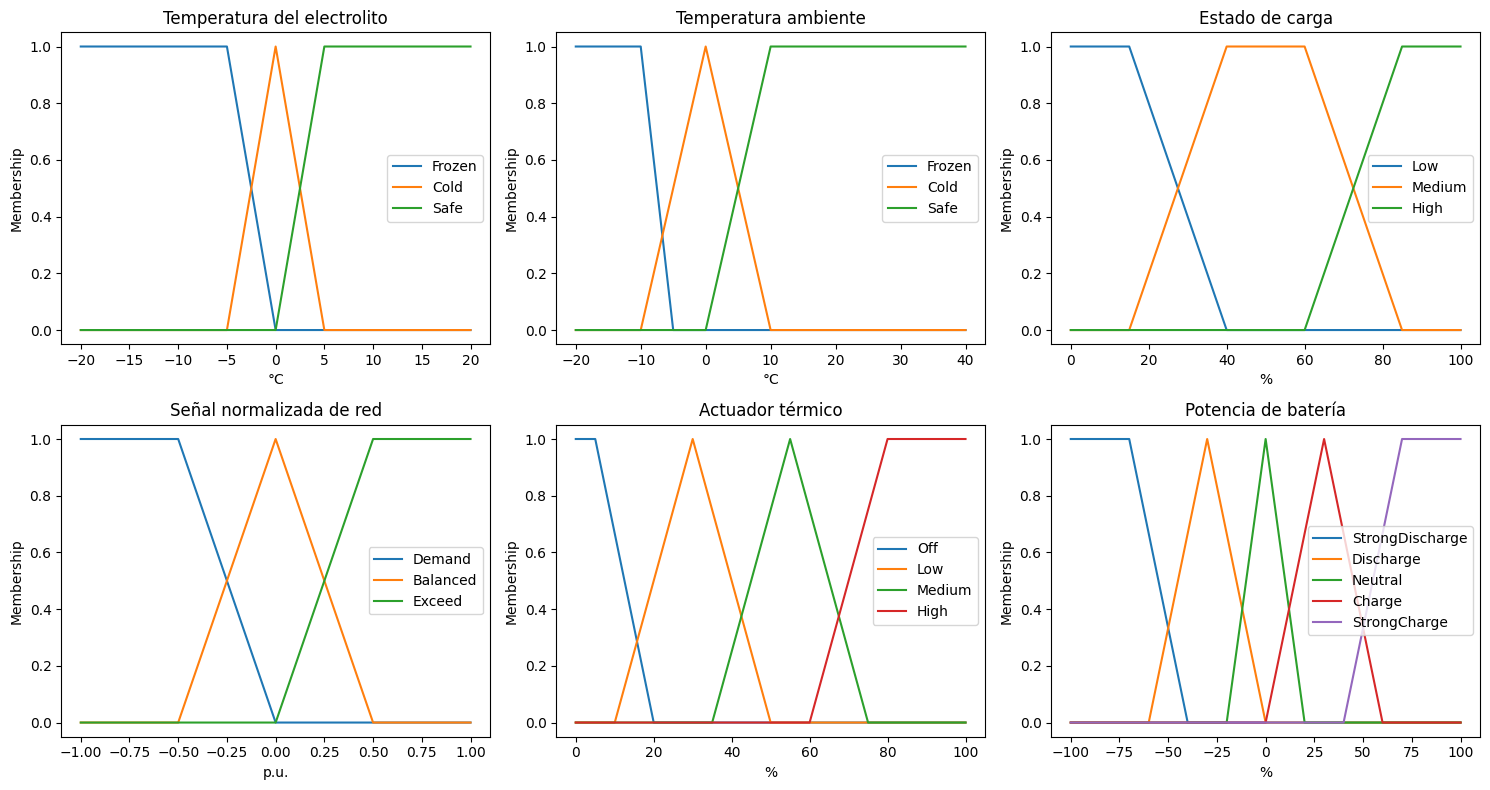

In [8]:
def plot_var(ax, var, titulo, xlabel):
    for etiqueta in var.terms:
        ax.plot(var.universe, var[etiqueta].mf, label=etiqueta)
    ax.set_title(titulo)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Membership')
    ax.legend()

fig, axs = plt.subplots(2, 3, figsize=(15, 8))
plot_var(axs[0, 0], temp_elec, 'Temperatura del electrolito', '°C')
plot_var(axs[0, 1], temp_amb_final, 'Temperatura ambiente', '°C')
plot_var(axs[0, 2], soc_v2, 'Estado de carga', '%')
plot_var(axs[1, 0], sgrid_v2, 'Señal normalizada de red', 'p.u.')
plot_var(axs[1, 1], heater, 'Actuador térmico', '%')
plot_var(axs[1, 2], batt, 'Potencia de batería', '%')
plt.tight_layout()
plt.show()

## 7. Escenarios de evaluación

Cinco combinaciones de entrada que ilustran distintas regiones del dominio.

In [9]:
casos_v4 = [
    ('Escenario 1 (Frozen,Low,Balanced)', -10, -10, 10, 0.0),
    ('Escenario 2 (Cold/Frozen,Med/High,Exceed)', -1, -1, 70, 1.0),
    ('Escenario 3 (Safe,Medium,Balanced)', 10, 10, 50, 0.0),
    ('Escenario 4 (Frozen,Low,Exceed)', -15, -15, 10, 1.0),
    ('Escenario 5 (Frozen,Low,Demand)', -10, -10, 10, -0.8),
]
filas_v4 = []
for nombre, te, ta, s, g in casos_v4:
    out = run_v4(te, ta, s, g)
    filas_v4.append({
        'Escenario': nombre,
        'heater_%': round(out['heater'], 1),
        'pump_%': round(out['pump'], 1),
        'batt_%': round(out['batt'], 1),
    })
tabla_v4 = pd.DataFrame(filas_v4)
tabla_v4


,Escenario,heater_%,pump_%,batt_%
0,"Escenario 1 (Frozen,Low,Balanced)",7.0,84.4,0.0
1,"Escenario 2 (Cold/Frozen,Med/High,Exceed)",41.6,51.4,21.0
2,"Escenario 3 (Safe,Medium,Balanced)",7.0,7.0,0.0
3,"Escenario 4 (Frozen,Low,Exceed)",84.4,55.0,76.7
4,"Escenario 5 (Frozen,Low,Demand)",7.0,84.4,0.0


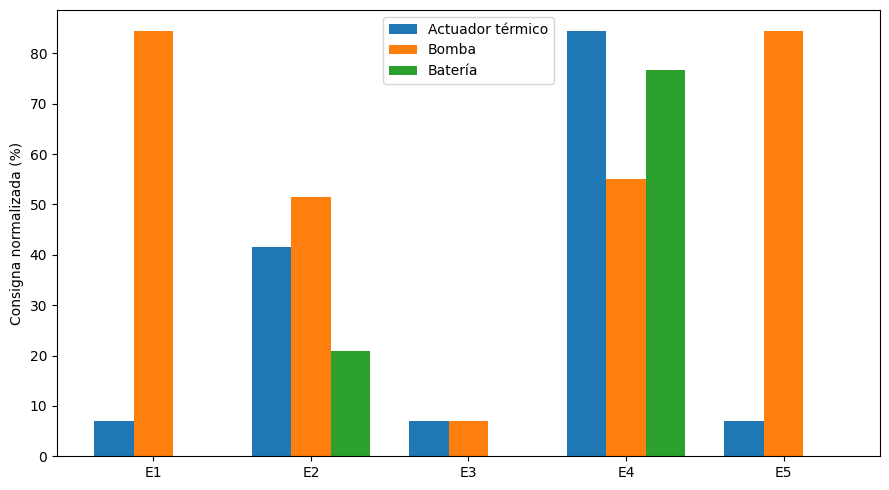

In [10]:
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(tabla_v4)); ancho = 0.25
ax.bar(x - ancho, tabla_v4['heater_%'], ancho, label='Actuador térmico', color='#1f77b4')
ax.bar(x,          tabla_v4['pump_%'],   ancho, label='Bomba',          color='#ff7f0e')
ax.bar(x + ancho,  tabla_v4['batt_%'],   ancho, label='Batería',        color='#2ca02c')
ax.set_xticks(x); ax.set_xticklabels(['E1', 'E2', 'E3', 'E4', 'E5'])
ax.set_ylabel('Consigna normalizada (%)')
ax.legend()
plt.tight_layout()
plt.savefig('fig_escenarios_barras.png', dpi=200)
plt.show()

## 8. Agregación y desfusificación de un caso

Para el escenario de frío intenso (temperatura del electrolito y ambiente en -15 °C, SoC 10 %, red en excedente), se muestran las funciones de pertenencia del actuador térmico, la región agregada de las reglas activadas y el centroide que determina la consigna final.

heater = 84.4 %  (Escenario 4)


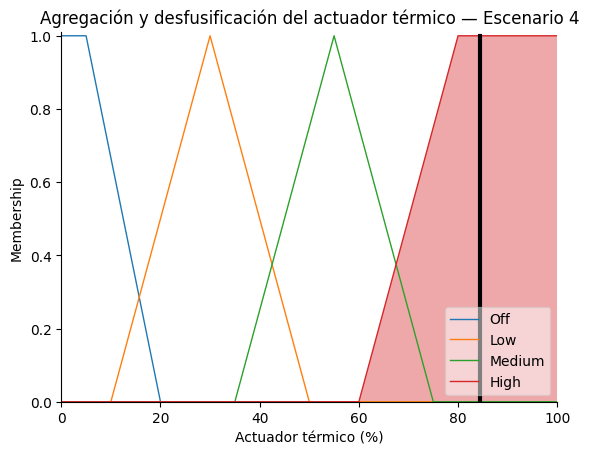

In [11]:
battery_v4.input['temp_elec'] = -15.0
battery_v4.input['temp_amb_final'] = -15.0
battery_v4.input['soc_v2'] = 10.0
battery_v4.input['sgrid_v2'] = 1.0
battery_v4.compute()
print(f"heater = {battery_v4.output['heater']:.1f} %  (Escenario 4)")

heater.view(sim=battery_v4)
ax = plt.gca()
ax.set_xlabel('Actuador térmico (%)')
ax.set_title('Agregación y desfusificación del actuador térmico — Escenario 4')
plt.savefig('fig_agregacion_actuador_termico_E4.png', dpi=200, bbox_inches='tight')
plt.show()

## 9. Verificación de cobertura

Comprobación de que el sistema produce las tres salidas, sin valores indefinidos, en 363 puntos de barridos deterministas y en 500 combinaciones aleatorias de las cuatro entradas.

In [12]:
# 5.8.c Las tres salidas existen y son finitas en los 363 puntos deterministas + 500 aleatorios (misma semilla que 5.4)
puntos = [(float(t), float(t), float(s), g)
          for g in (-0.8, 0.0, 0.8) for t in np.arange(-20, 21, 4) for s in np.arange(0, 101, 10)]
n_det = len(puntos)
rng = np.random.default_rng(7)
for _ in range(500):
    te = rng.uniform(-20, 20); ta = rng.uniform(-20, 40)
    s = rng.uniform(0, 100); g = rng.uniform(-1, 1)
    puntos.append((te, ta, s, g))

res = np.full((len(puntos), 3), np.nan)
fallos = 0
for i, p in enumerate(puntos):
    try:
        out = run_v4(*p)
        assert set(out.keys()) == {'heater', 'pump', 'batt'}
        res[i] = [out['heater'], out['pump'], out['batt']]
    except Exception:
        fallos += 1
print(f'Puntos evaluados: {len(puntos)} ({n_det} deterministas + {len(puntos) - n_det} aleatorios); fallos: {fallos}; salidas no finitas: {(~np.isfinite(res)).sum()}')
for j, nombre in enumerate(['heater', 'pump', 'batt']):
    print(f'  {nombre:6s}: mín = {np.nanmin(res[:, j]):6.1f} %   máx = {np.nanmax(res[:, j]):6.1f} %')
assert fallos == 0 and np.isfinite(res).all()

Puntos evaluados: 863 (363 deterministas + 500 aleatorios); fallos: 0; salidas no finitas: 0
  heater: mín =    7.0 %   máx =   84.4 %
  pump  : mín =    7.0 %   máx =   84.4 %
  batt  : mín =  -30.0 %   máx =   76.7 %


### Centroides de las etiquetas de salida

In [13]:
# 5.8.a Centroides de las etiquetas de salida
CENT_HP = {l: float(fuzz.centroid(heater.universe, heater[l].mf)) for l in ['Off', 'Low', 'Medium', 'High']}
CENT_PUMP = {l: float(fuzz.centroid(pump.universe, pump[l].mf)) for l in ['Off', 'Low', 'Medium', 'High']}
CENT_B = {l: float(fuzz.centroid(batt.universe, batt[l].mf)) for l in ['StrongDischarge', 'Discharge', 'Neutral', 'Charge', 'StrongCharge']}
print('heater :', {k: round(v, 2) for k, v in CENT_HP.items()})
print('pump   :', {k: round(v, 2) for k, v in CENT_PUMP.items()})
print('batt   :', {k: round(v, 2) for k, v in CENT_B.items()})

# 5.8.b Decisiones distintas de la tabla de 27 filas
import collections
trios = collections.Counter(DECISION_V2.values())
print(f'\nLas 27 decisiones de DECISION_V2 corresponden a {len(trios)} tríos (heater, pump, batt) distintos:')
for k, v in trios.most_common():
    print(f'  {v:2d} filas -> {k}')

heater : {'Off': 7.0, 'Low': 30.0, 'Medium': 55.0, 'High': 84.44}
pump   : {'Off': 7.0, 'Low': 30.0, 'Medium': 55.0, 'High': 84.44}
batt   : {'StrongDischarge': -76.67, 'Discharge': -30.0, 'Neutral': 0.0, 'Charge': 30.0, 'StrongCharge': 76.67}

Las 27 decisiones de DECISION_V2 corresponden a 8 tríos (heater, pump, batt) distintos:
   9 filas -> ('Off', 'Off', 'Neutral')
   4 filas -> ('Off', 'High', 'Neutral')
   4 filas -> ('Off', 'Medium', 'Neutral')
   3 filas -> ('Medium', 'Medium', 'Charge')
   3 filas -> ('Off', 'Low', 'Neutral')
   2 filas -> ('Medium', 'Medium', 'Discharge')
   1 filas -> ('High', 'Medium', 'StrongCharge')
   1 filas -> ('Low', 'High', 'Neutral')


## 10. Superficies estáticas

Demand: 0 / 121 puntos sin salida
Balanced: 0 / 121 puntos sin salida
Exceed: 0 / 121 puntos sin salida


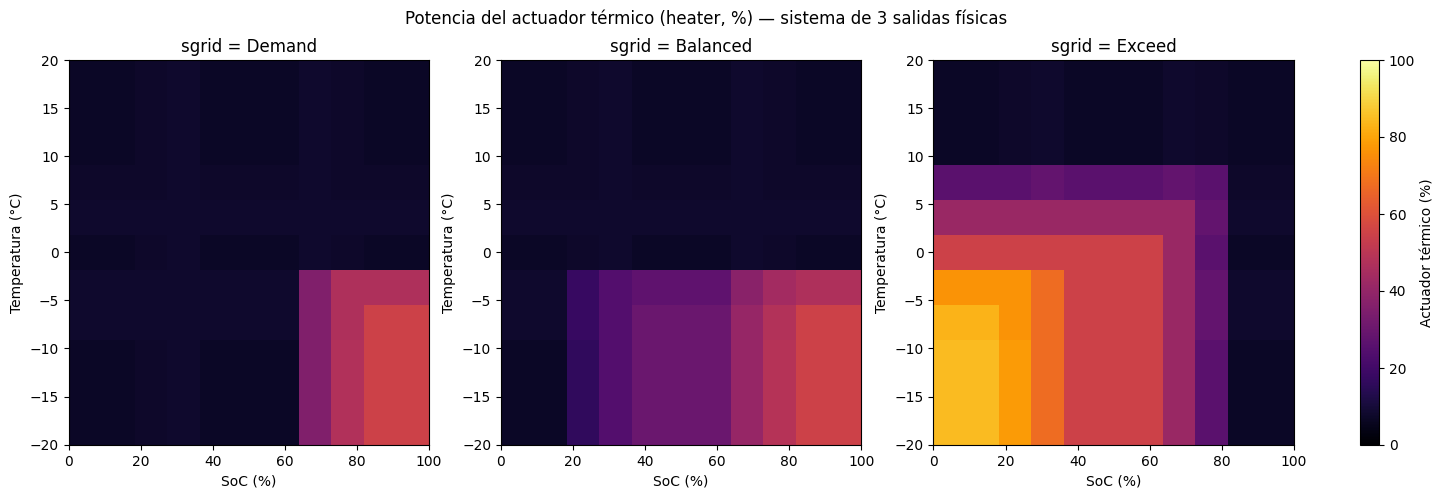

In [14]:
temps_v4 = np.arange(-20, 21, 4)
socs_v4 = np.arange(0, 101, 10)

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for ax, (g_val, g_nombre) in zip(axes, [(-0.8, 'Demand'), (0.0, 'Balanced'), (0.8, 'Exceed')]):
    Z = np.full((len(temps_v4), len(socs_v4)), np.nan)
    for i, t in enumerate(temps_v4):
        for j, s in enumerate(socs_v4):
            try:
                Z[i, j] = run_v4(float(t), float(t), float(s), g_val)['heater']
            except Exception:
                pass
    im = ax.imshow(Z, aspect='auto', origin='lower',
                    extent=[socs_v4.min(), socs_v4.max(), temps_v4.min(), temps_v4.max()],
                    cmap='inferno', vmin=0, vmax=100)
    ax.set_title(f'sgrid = {g_nombre}')
    ax.set_xlabel('SoC (%)')
    ax.set_ylabel('Temperatura (°C)')
    print(f'{g_nombre}: {np.isnan(Z).sum()} / {Z.size} puntos sin salida')

fig.suptitle('Potencia del actuador térmico (heater, %) — sistema de 3 salidas físicas')
fig.colorbar(im, ax=axes, label='Actuador térmico (%)', fraction=0.02)
plt.show()


## 11. Efecto de la temperatura ambiente

In [15]:
for ta in [30, 10, -1, -10, -18]:
    out = run_v4(-2, ta, 90, -0.8)
    print(f"temp_amb={ta:6.1f} °C -> heater={out['heater']:5.1f}%  "
          f"pump={out['pump']:5.1f}%  batt={out['batt']:6.1f}%")


temp_amb=  30.0 °C -> heater= 35.2%  pump= 40.6%  batt= -16.7%
temp_amb=  10.0 °C -> heater= 35.2%  pump= 40.6%  batt= -16.7%


temp_amb=  -1.0 °C -> heater= 35.2%  pump= 40.6%  batt= -16.7%
temp_amb= -10.0 °C -> heater= 55.0%  pump= 55.0%  batt= -30.0%
temp_amb= -18.0 °C -> heater= 55.0%  pump= 55.0%  batt= -30.0%


## 12. Comprobaciones de consistencia

Unicidad de las 81 combinaciones lingüísticas, coherencia del consecuente de cada regla con la tabla de decisión, y ausencia de saltos bruscos en la superficie de salida.

In [16]:
# 7.1.a Unicidad de antecedentes
claves_regla = set()
duplicados = 0
for te_lbl, ta_lbl, soc_lbl, g_lbl in itertools.product(
        ['Frozen', 'Cold', 'Safe'], ['Frozen', 'Cold', 'Safe'],
        ['Low', 'Medium', 'High'], ['Demand', 'Balanced', 'Exceed']):
    clave = (te_lbl, ta_lbl, soc_lbl, g_lbl)
    if clave in claves_regla:
        duplicados += 1
    claves_regla.add(clave)
print(f'Combinaciones únicas: {len(claves_regla)} / 81 esperadas. Duplicados (reglas que se pisan): {duplicados}')

# 7.1.b Monotonicidad: a más riesgo térmico, la acción no debe bajar de intensidad
NIVEL = {'Off': 0, 'Low': 1, 'Medium': 2, 'High': 3}
violaciones = []
for soc_lbl in ['Low', 'Medium', 'High']:
    for g_lbl in ['Demand', 'Balanced', 'Exceed']:
        h_safe, p_safe, _ = DECISION_V2[('Safe', soc_lbl, g_lbl)]
        h_cold, p_cold, _ = DECISION_V2[('Cold', soc_lbl, g_lbl)]
        h_frozen, p_frozen, _ = DECISION_V2[('Frozen', soc_lbl, g_lbl)]
        if not (NIVEL[h_safe] <= NIVEL[h_cold] <= NIVEL[h_frozen]):
            violaciones.append(('heater', soc_lbl, g_lbl, h_safe, h_cold, h_frozen))
        if not (NIVEL[p_safe] <= NIVEL[p_cold] <= NIVEL[p_frozen]):
            violaciones.append(('pump', soc_lbl, g_lbl, p_safe, p_cold, p_frozen))

print(f'Violaciones de monotonicidad: {len(violaciones)}')
for v in violaciones:
    print(' ', v)


Combinaciones únicas: 81 / 81 esperadas. Duplicados (reglas que se pisan): 0
Violaciones de monotonicidad: 0


In [17]:
def _etq(t):  # etiqueta de un término de salida (WeightedTerm) o de entrada (Term)
    return t.term.label if hasattr(t, 'term') else t.label

claves_reales, desajustes = {}, []
for r in rules_v4:
    ant = {t.parent.label: t.label for t in r.antecedent_terms}
    clave = (ant['temp_elec'], ant['temp_amb_final'], ant['soc_v2'], ant['sgrid_v2'])
    claves_reales.setdefault(clave, []).append(r)
    esperado = DECISION_V2[(effective_temp_label(clave[0], clave[1]), clave[2], clave[3])]
    obtenido = tuple(_etq(t) for t in r.consequent)
    if obtenido != esperado:
        desajustes.append((clave, esperado, obtenido))

print(f'Reglas: {len(rules_v4)}; antecedentes distintos: {len(claves_reales)}')
print('Antecedentes repetidos:', sum(len(v) > 1 for v in claves_reales.values()))
print('Reglas cuyo consecuente no coincide con DECISION_V2:', len(desajustes))
assert len(rules_v4) == len(claves_reales) == 81 and not desajustes

Reglas: 81; antecedentes distintos: 81
Antecedentes repetidos: 0
Reglas cuyo consecuente no coincide con DECISION_V2: 0


In [18]:
temps_cont = np.arange(-20, 21, 2)
socs_cont = np.arange(0, 101, 5)
UMBRAL_SALTO = 30  # puntos porcentuales entre vecinos

for g_val, g_nombre in [(-0.8, 'Demand'), (0.0, 'Balanced'), (0.8, 'Exceed')]:
    Z = np.zeros((len(temps_cont), len(socs_cont)))
    for i, t in enumerate(temps_cont):
        for j, s in enumerate(socs_cont):
            battery_v4.input['temp_elec'] = float(t)
            battery_v4.input['temp_amb_final'] = float(t)
            battery_v4.input['soc_v2'] = float(s)
            battery_v4.input['sgrid_v2'] = g_val
            battery_v4.compute()
            Z[i, j] = battery_v4.output['heater']
    salto_temp = np.abs(np.diff(Z, axis=0))
    salto_soc = np.abs(np.diff(Z, axis=1))
    salto_max = max(salto_temp.max(), salto_soc.max())
    n_saltos = (salto_temp > UMBRAL_SALTO).sum() + (salto_soc > UMBRAL_SALTO).sum()
    print(f'sgrid={g_nombre:9s}: salto máx. entre vecinos = {salto_max:5.1f} pp; '
          f'saltos > {UMBRAL_SALTO}pp: {n_saltos}')


sgrid=Demand   : salto máx. entre vecinos =  28.2 pp; saltos > 30pp: 0


sgrid=Balanced : salto máx. entre vecinos =  28.2 pp; saltos > 30pp: 0


sgrid=Exceed   : salto máx. entre vecinos =  23.9 pp; saltos > 30pp: 0


## 13. Trayectoria sintética de 24 horas

In [19]:
from scipy.ndimage import uniform_filter1d

# --- Perfil sintético de un día de invierno (24 h, resolución 15 min) ---
horas = np.arange(0, 24, 0.25)

# Temperatura ambiente: mínimo antes del amanecer (~6-7h), máximo a media tarde (~15h)
temp_amb_t = -6 + 9 * (0.5 - 0.5*np.cos(2*np.pi*(horas-7)/24)) - 3*np.exp(-((horas-6)**2)/8)
temp_amb_t = np.clip(temp_amb_t, -20, 40)

# Temperatura del electrolito: versión suavizada/retardada de la ambiente (inercia térmica del tanque)
temp_elec_t = uniform_filter1d(np.roll(temp_amb_t, 6), size=12, mode='wrap') + 2

# sgrid: excedente solar a mediodía, demanda en las puntas (8-10h y 19-21h)
sgrid_t = (0.6*np.exp(-((horas-13)**2)/8)
           - 0.7*np.exp(-((horas-9)**2)/2)
           - 0.8*np.exp(-((horas-20)**2)/2))
sgrid_t = np.clip(sgrid_t, -1, 1)

# soc: sube con el excedente solar, baja en las puntas de demanda (proxy simplificado, no un balance energético real)
soc_t = 40 + 30*np.cumsum(sgrid_t)/np.sum(np.abs(sgrid_t))*3
soc_t = np.clip(soc_t, 5, 95)

heater_t, pump_t, batt_t = [], [], []
for i in range(len(horas)):
    battery_v4.input['temp_elec'] = float(temp_elec_t[i])
    battery_v4.input['temp_amb_final'] = float(temp_amb_t[i])
    battery_v4.input['soc_v2'] = float(soc_t[i])
    battery_v4.input['sgrid_v2'] = float(sgrid_t[i])
    battery_v4.compute()
    heater_t.append(battery_v4.output['heater'])
    pump_t.append(battery_v4.output['pump'])
    batt_t.append(battery_v4.output['batt'])

print(f'Simulación completada: {len(horas)} pasos de 15 min a lo largo de 24 h')


Simulación completada: 96 pasos de 15 min a lo largo de 24 h


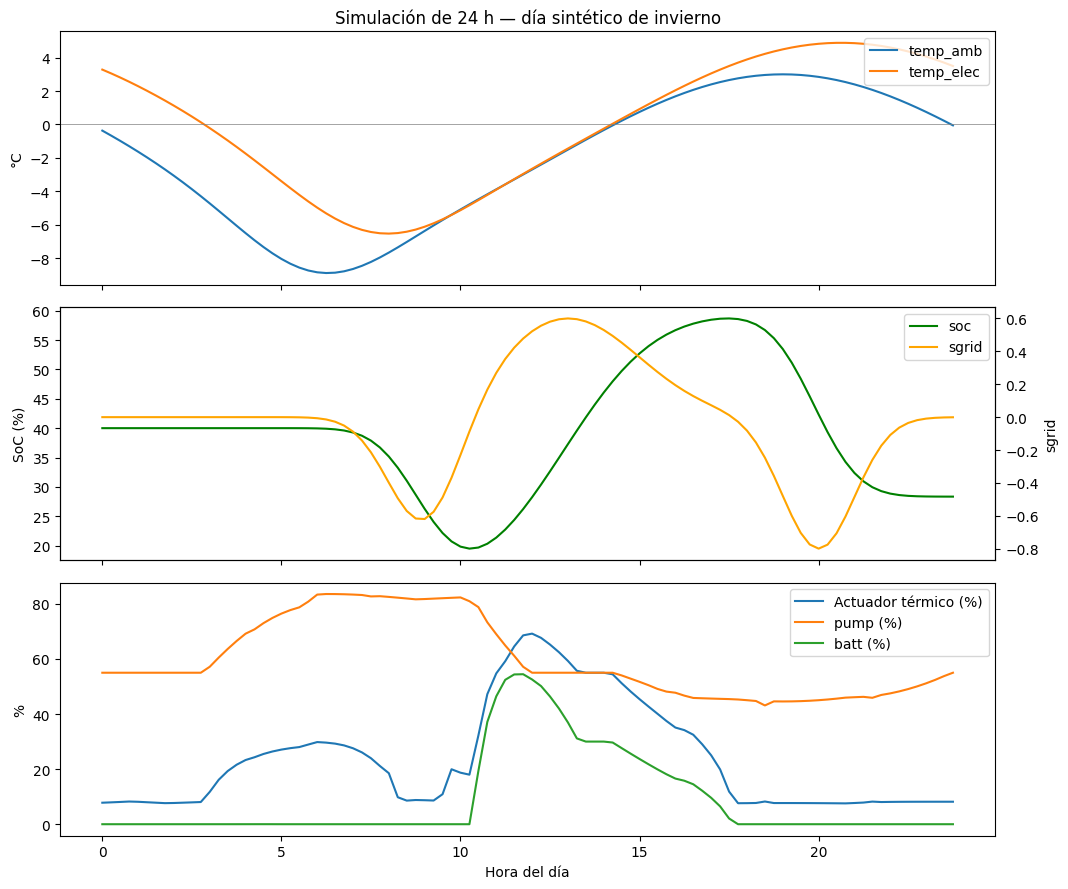

In [20]:
fig, axes = plt.subplots(3, 1, figsize=(11, 9), sharex=True)

axes[0].plot(horas, temp_amb_t, label='temp_amb')
axes[0].plot(horas, temp_elec_t, label='temp_elec')
axes[0].axhline(0, color='gray', lw=0.5)
axes[0].set_ylabel('°C')
axes[0].legend(loc='upper right')
axes[0].set_title('Simulación de 24 h — día sintético de invierno')

axes[1].plot(horas, soc_t, label='soc', color='green')
axes[1].set_ylabel('SoC (%)')
ax2 = axes[1].twinx()
ax2.plot(horas, sgrid_t, label='sgrid', color='orange')
ax2.set_ylabel('sgrid')
lines1, labels1 = axes[1].get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
axes[1].legend(lines1 + lines2, labels1 + labels2, loc='upper right')

axes[2].plot(horas, heater_t, label='Actuador térmico (%)')
axes[2].plot(horas, pump_t, label='pump (%)')
axes[2].plot(horas, batt_t, label='batt (%)')
axes[2].set_ylabel('%')
axes[2].set_xlabel('Hora del día')
axes[2].legend(loc='upper right')

plt.tight_layout()
plt.show()


## 14. Comparación con controladores por umbrales

Dos controladores por umbrales (uno con fronteras en los extremos de las funciones de pertenencia, otro con fronteras en los puntos de cruce y salidas en el centroide de cada etiqueta) frente al supervisor difuso, en un único corte del dominio.

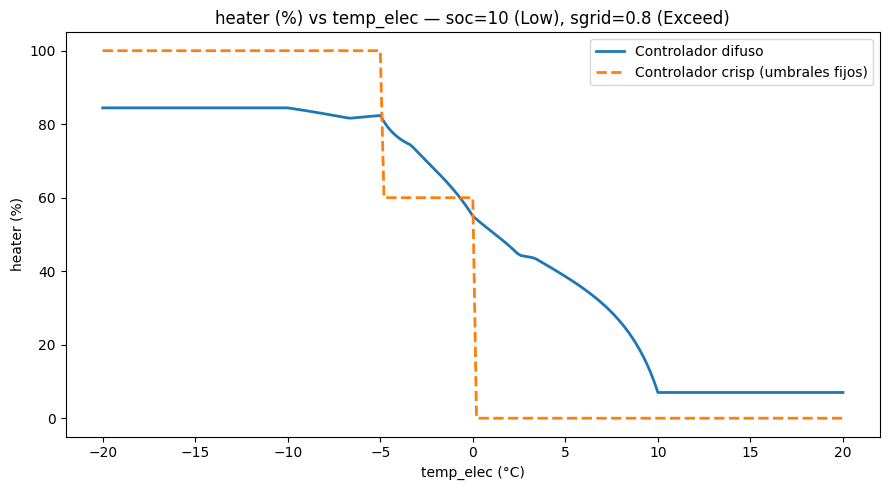

Salto máximo crisp: 60.0 pp
Salto máximo difuso: 2.9 pp
Nº de saltos > 20 pp — crisp: 2, difuso: 0


In [21]:
def etiqueta_crisp(t_elec):
    if t_elec < -5: return 'Frozen'
    elif t_elec < 0: return 'Cold'
    else: return 'Safe'

def controlador_crisp(t_elec, t_amb, s, g):
    te_lbl = etiqueta_crisp(t_elec)
    ta_lbl = etiqueta_crisp(t_amb)
    eff = effective_temp_label(te_lbl, ta_lbl)
    soc_lbl = 'Low' if s < 40 else ('Medium' if s < 85 else 'High')
    g_lbl = 'Demand' if g < -0.5 else ('Exceed' if g > 0.5 else 'Balanced')
    h_lvl, p_lvl, b_lvl = DECISION_V2[(eff, soc_lbl, g_lbl)]
    NIVEL_A_PCT = {'Off': 0, 'Low': 30, 'Medium': 60, 'High': 100}
    BATT_A_PCT = {'StrongDischarge': -90, 'Discharge': -45, 'Neutral': 0, 'Charge': 45, 'StrongCharge': 90}
    return NIVEL_A_PCT[h_lvl], NIVEL_A_PCT[p_lvl], BATT_A_PCT[b_lvl]

# Comparación 1D: heater vs temp_elec, con soc=10 (Low) y sgrid=0.8 (Exceed) fijos
temps_linea = np.arange(-20, 20.1, 0.2)
heater_difuso, heater_crisp = [], []
for t in temps_linea:
    battery_v4.input['temp_elec'] = float(t)
    battery_v4.input['temp_amb_final'] = float(t)
    battery_v4.input['soc_v2'] = 10.0
    battery_v4.input['sgrid_v2'] = 0.8
    battery_v4.compute()
    heater_difuso.append(battery_v4.output['heater'])
    heater_crisp.append(controlador_crisp(t, t, 10.0, 0.8)[0])

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(temps_linea, heater_difuso, label='Controlador difuso', lw=2)
ax.plot(temps_linea, heater_crisp, label='Controlador crisp (umbrales fijos)', lw=2, linestyle='--')
ax.set_xlabel('temp_elec (°C)'); ax.set_ylabel('heater (%)')
ax.set_title('heater (%) vs temp_elec — soc=10 (Low), sgrid=0.8 (Exceed)')
ax.legend()
plt.tight_layout()
plt.show()

saltos_crisp = np.abs(np.diff(heater_crisp))
saltos_difuso = np.abs(np.diff(heater_difuso))
print(f'Salto máximo crisp: {saltos_crisp.max():.1f} pp')
print(f'Salto máximo difuso: {saltos_difuso.max():.1f} pp')
print(f'Nº de saltos > 20 pp — crisp: {(saltos_crisp>20).sum()}, difuso: {(saltos_difuso>20).sum()}')


{'temp_elec': (-2.5, 2.5), 'temp_amb': (-6.67, 5.0), 'soc': (27.5, 72.5), 'sgrid': (-0.25, 0.25)}
Umbral (cortes en extremos)  : salto máx. = 60.0 pp
Umbral (cortes equitativos)  : salto máx. = 48.0 pp; saltos > 20 pp: 2
Supervisor difuso           : salto máx. entre muestras = 2.9 pp (paso 0.2 °C) -> pendiente máx. = 14.6 pp/°C; saltos > 20 pp: 0


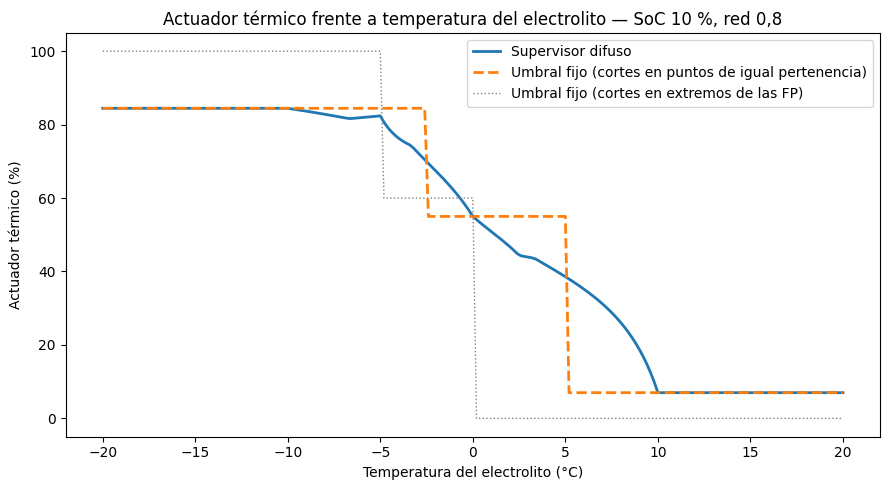

In [22]:
# 9.1 Baseline crisp equitativo
def punto_cruce(var, a, b):
    """Valor de la variable donde las funciones de pertenencia de a y b son iguales (entre sus picos)."""
    u = var.universe
    pa, pb = u[np.argmax(var[a].mf)], u[np.argmax(var[b].mf)]
    x = np.linspace(min(pa, pb), max(pa, pb), 20001)
    dif = np.abs(np.interp(x, u, var[a].mf) - np.interp(x, u, var[b].mf))
    return float(x[np.argmin(dif)])

CRUCES = {
    'temp_elec': (punto_cruce(temp_elec, 'Frozen', 'Cold'), punto_cruce(temp_elec, 'Cold', 'Safe')),
    'temp_amb':  (punto_cruce(temp_amb_final, 'Frozen', 'Cold'), punto_cruce(temp_amb_final, 'Cold', 'Safe')),
    'soc':       (punto_cruce(soc_v2, 'Low', 'Medium'), punto_cruce(soc_v2, 'Medium', 'High')),
    'sgrid':     (punto_cruce(sgrid_v2, 'Demand', 'Balanced'), punto_cruce(sgrid_v2, 'Balanced', 'Exceed')),
}
print({k: tuple(round(x, 2) for x in v) for k, v in CRUCES.items()})

def _nivel(x, cortes, etiquetas):
    return etiquetas[0] if x < cortes[0] else (etiquetas[1] if x < cortes[1] else etiquetas[2])

def controlador_crisp_eq(t_elec, t_amb, s, g):
    te = _nivel(t_elec, CRUCES['temp_elec'], ['Frozen', 'Cold', 'Safe'])
    ta = _nivel(t_amb, CRUCES['temp_amb'], ['Frozen', 'Cold', 'Safe'])
    sl = _nivel(s, CRUCES['soc'], ['Low', 'Medium', 'High'])
    gl = _nivel(g, CRUCES['sgrid'], ['Demand', 'Balanced', 'Exceed'])
    h, p, b = DECISION_V2[(effective_temp_label(te, ta), sl, gl)]
    return CENT_HP[h], CENT_PUMP[p], CENT_B[b]

# Mismo corte que en la sección 9 (soc = 10, sgrid = 0,8, temp_amb = temp_elec), reutilizando temps_linea y heater_difuso
heater_crisp_eq = [controlador_crisp_eq(t, t, 10.0, 0.8)[0] for t in temps_linea]
paso = float(temps_linea[1] - temps_linea[0])
sal_eq = np.abs(np.diff(heater_crisp_eq))
sal_df = np.abs(np.diff(heater_difuso))
print(f'Umbral (cortes en extremos)  : salto máx. = {saltos_crisp.max():.1f} pp')
print(f'Umbral (cortes equitativos)  : salto máx. = {sal_eq.max():.1f} pp; saltos > 20 pp: {(sal_eq > 20).sum()}')
print(f'Supervisor difuso           : salto máx. entre muestras = {sal_df.max():.1f} pp (paso {paso:.1f} °C) '
      f'-> pendiente máx. = {sal_df.max() / paso:.1f} pp/°C; saltos > 20 pp: {(sal_df > 20).sum()}')

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(temps_linea, heater_difuso, lw=2, label='Supervisor difuso')
ax.plot(temps_linea, heater_crisp_eq, lw=2, ls='--', label='Umbral fijo (cortes en puntos de igual pertenencia)')
ax.plot(temps_linea, heater_crisp, lw=1, ls=':', color='gray', label='Umbral fijo (cortes en extremos de las FP)')
ax.set_xlabel('Temperatura del electrolito (°C)'); ax.set_ylabel('Actuador térmico (%)')
ax.set_title('Actuador térmico frente a temperatura del electrolito — SoC 10 %, red 0,8')
ax.legend(); plt.tight_layout()
plt.savefig('fig_comparacion_umbrales_eq.png', dpi=200)
plt.show()

## 15. Contraste de los umbrales con literatura publicada

Los puntos de ruptura de `temp_elec` se fijaron por criterio experto. Esta sección los contrasta con dos fuentes verificadas sobre el comportamiento térmico de baterías de flujo de vanadio a baja temperatura.

In [23]:
tabla_literatura = pd.DataFrame([
    {
        'Umbral del supervisor': "'Frozen' empieza en 0 °C, pleno a -5 °C",
        'Literatura verificada': 'Precipitación de V(II) a baja temperatura en el electrolito negativo; depende de la formulación (solubilidad ensayada a -5 °C; electrolito modificado estable a -10 °C)',
        'Fuente': 'Zhan et al. 2026',
    },
    {
        'Umbral del supervisor': "Acciones de carga/descarga para calentar (tabla de decisión)",
        'Literatura verificada': 'En su configuración experimental, la temperatura sube en descarga y baja respecto a la exterior en carga',
        'Fuente': 'Rho et al. 2022',
    },
])
tabla_literatura

,Umbral del supervisor,Literatura verificada,Fuente
0,"'Frozen' empieza en 0 °C, pleno a -5 °C",Precipitación de V(II) a baja temperatura en e...,Zhan et al. 2026
1,Acciones de carga/descarga para calentar (tabl...,"En su configuración experimental, la temperatu...",Rho et al. 2022


**Lectura:** ninguna de las dos fuentes valida directamente los umbrales como límites físicos; ambas muestran que la relación entre temperatura y modo de operación (carga/descarga) depende de la formulación del electrolito y de las condiciones experimentales. Los umbrales del supervisor deben tratarse como hipótesis de diseño pendientes de calibración.

## 16. Traducción ilustrativa a magnitudes físicas

Usando la potencia nominal de una VRFB de referencia (90 kW), se traduce la consigna de batería a kilovatios y se compara la corriente resultante con los límites reales de un convertidor típico (440 A en carga, 600 A en descarga). Es un ejercicio ilustrativo: no valida ni calibra el supervisor.

In [24]:
# 9.2 Datos de placa reales (VRFB de referencia, CEDER-CIEMAT) y traducción ilustrativa de 'batt'
P_NOMINAL_KW = 90.0
V_STACK_MIN, V_STACK_MAX = 300.0, 465.0
I_CARGA_MAX_A = 440.0
I_DESCARGA_MAX_A = 600.0
T_CARGA_MAX_C = 40.0        # límite real de placa: no cargar si el electrolito supera esta temperatura
T_DESCARGA_MAX_C = 45.0     # límite real de placa: no descargar si el electrolito supera esta temperatura
OCV_CARGA_V, OCV_DESCARGA_V = 1.5, 1.3  # límites reales de tensión de circuito abierto (carga / descarga)

# batt (%) de la Tabla 4 del artículo (tabla_v4), por escenario
casos_fisicos_reales = [('Escenario 1', 0.0), ('Escenario 2', 21.0), ('Escenario 3', 0.0),
                         ('Escenario 4', 76.7), ('Escenario 5', 0.0)]
filas = []
for nombre, batt_pct in casos_fisicos_reales:
    p_kw = batt_pct / 100.0 * P_NOMINAL_KW
    if p_kw == 0:
        i_txt, limite, pct_limite = '0', '-', '0'
    else:
        i_min = abs(p_kw) * 1000 / V_STACK_MAX
        i_max = abs(p_kw) * 1000 / V_STACK_MIN
        limite = I_CARGA_MAX_A if p_kw > 0 else I_DESCARGA_MAX_A
        i_txt = f'{i_min:.0f}-{i_max:.0f}'
        pct_limite = f'{100 * i_max / limite:.0f}'
    filas.append({'Escenario': nombre, 'batt (%)': batt_pct, 'P (kW)': round(p_kw, 1),
                  'I estimada (A)': i_txt, 'Límite real del convertidor (A)': limite,
                  '% del límite real': pct_limite})
tabla_fisica_real = pd.DataFrame(filas)
tabla_fisica_real

,Escenario,batt (%),P (kW),I estimada (A),Límite real del convertidor (A),% del límite real
0,Escenario 1,0.0,0.0,0,-,0
1,Escenario 2,21.0,18.9,41-63,440.0,14
2,Escenario 3,0.0,0.0,0,-,0
3,Escenario 4,76.7,69.0,148-230,440.0,52
4,Escenario 5,0.0,0.0,0,-,0


In [25]:
# Brecha entre el universo térmico del supervisor y los límites reales de temperatura
print(f'Universo de temp_elec del supervisor: -20 a 20 °C (Safe con pertenencia 1 desde 5 °C)')
print(f'Límite real de placa: no cargar por encima de {T_CARGA_MAX_C:.0f} °C; no descargar por encima de {T_DESCARGA_MAX_C:.0f} °C')
print('El supervisor no modela esta franja (20-45 °C): confirma, con cifras reales, la limitación ya')
print('declarada en el artículo sobre la ausencia de una estrategia frente al sobrecalentamiento.')
print()
print(f'Límites reales de OCV: carga hasta {OCV_CARGA_V} V; descarga hasta {OCV_DESCARGA_V} V')
print('Esta es la capa de protección determinista, independiente del SoC, que ya opera en la instalación real.')

Universo de temp_elec del supervisor: -20 a 20 °C (Safe con pertenencia 1 desde 5 °C)
Límite real de placa: no cargar por encima de 40 °C; no descargar por encima de 45 °C
El supervisor no modela esta franja (20-45 °C): confirma, con cifras reales, la limitación ya
declarada en el artículo sobre la ausencia de una estrategia frente al sobrecalentamiento.

Límites reales de OCV: carga hasta 1.5 V; descarga hasta 1.3 V
Esta es la capa de protección determinista, independiente del SoC, que ya opera en la instalación real.
